Average votes per restaurant: 156.91

Most Common Rating Range: 3-3.5 (2502 restaurants)


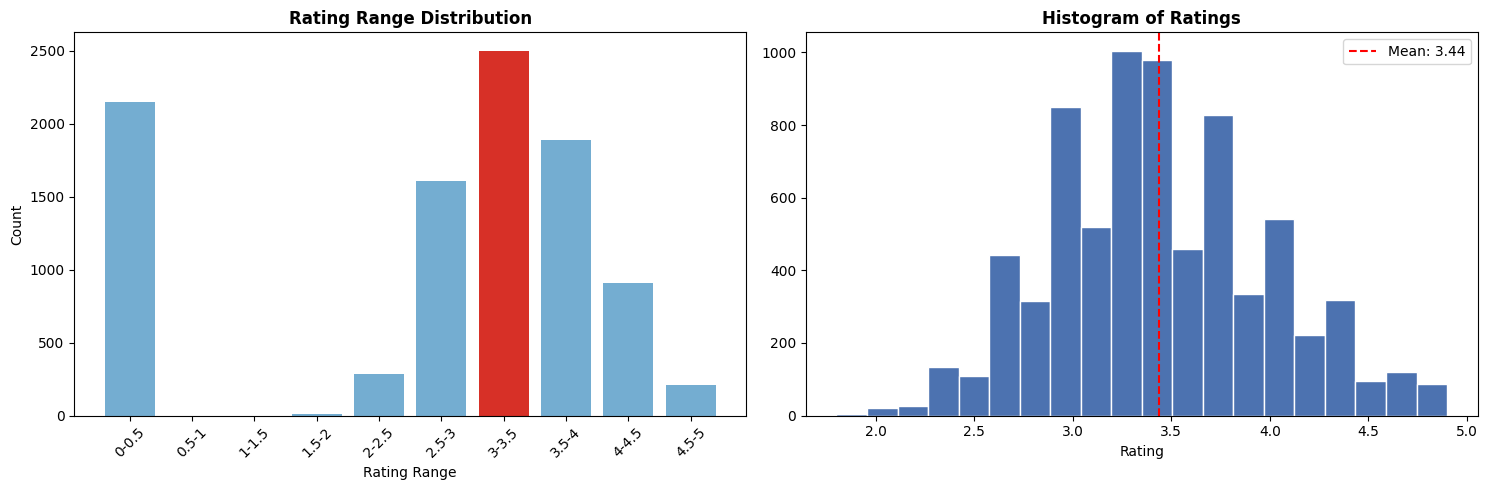

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/Dataset .csv')

# Clean column names (replace spaces and special characters with underscores)
df.columns = df.columns.str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

# Level 2 - Task 1: Restaurant Ratings

avg_votes = df["Votes"].mean()
print(f"Average votes per restaurant: {avg_votes:.2f}")

bins   = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
labels = ["0-0.5","0.5-1","1-1.5","1.5-2","2-2.5","2.5-3","3-3.5","3.5-4","4-4.5","4.5-5"]
df["Rating Range"] = pd.cut(df["Aggregate_rating"], bins=bins, labels=labels, include_lowest=True)

rating_dist = df["Rating Range"].value_counts().sort_index()
print(f"\nMost Common Rating Range: {rating_dist.idxmax()} ({rating_dist.max()} restaurants)")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = ["#d73027" if lbl == rating_dist.idxmax() else "#74add1" for lbl in rating_dist.index]
axes[0].bar(rating_dist.index, rating_dist.values, color=colors)
axes[0].set_title("Rating Range Distribution", fontweight="bold")
axes[0].set_xlabel("Rating Range")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

rated = df[df["Aggregate_rating"] > 0]["Aggregate_rating"]
axes[1].hist(rated, bins=20, color="#4C72B0", edgecolor="white")
axes[1].axvline(rated.mean(), color="red", linestyle="--", label=f"Mean: {rated.mean():.2f}")
axes[1].set_title("Histogram of Ratings", fontweight="bold")
axes[1].set_xlabel("Rating")
axes[1].legend()

plt.tight_layout()
plt.show()

Top 10 Most Common Cuisine Combinations
  Chinese + North Indian                   Count: 1784  Avg Rating: 3.25
  Mughlai + North Indian                   Count: 832  Avg Rating: 3.26
  Fast Food + North Indian                 Count: 485  Avg Rating: 3.18
  Continental + North Indian               Count: 468  Avg Rating: 3.62
  Chinese + Fast Food                      Count: 466  Avg Rating: 3.18
  North Indian + South Indian              Count: 405  Avg Rating: 3.22
  Chinese + Mughlai                        Count: 379  Avg Rating: 3.16
  Chinese + South Indian                   Count: 346  Avg Rating: 3.17
  Chinese + Continental                    Count: 303  Avg Rating: 3.57
  Italian + North Indian                   Count: 295  Avg Rating: 3.70


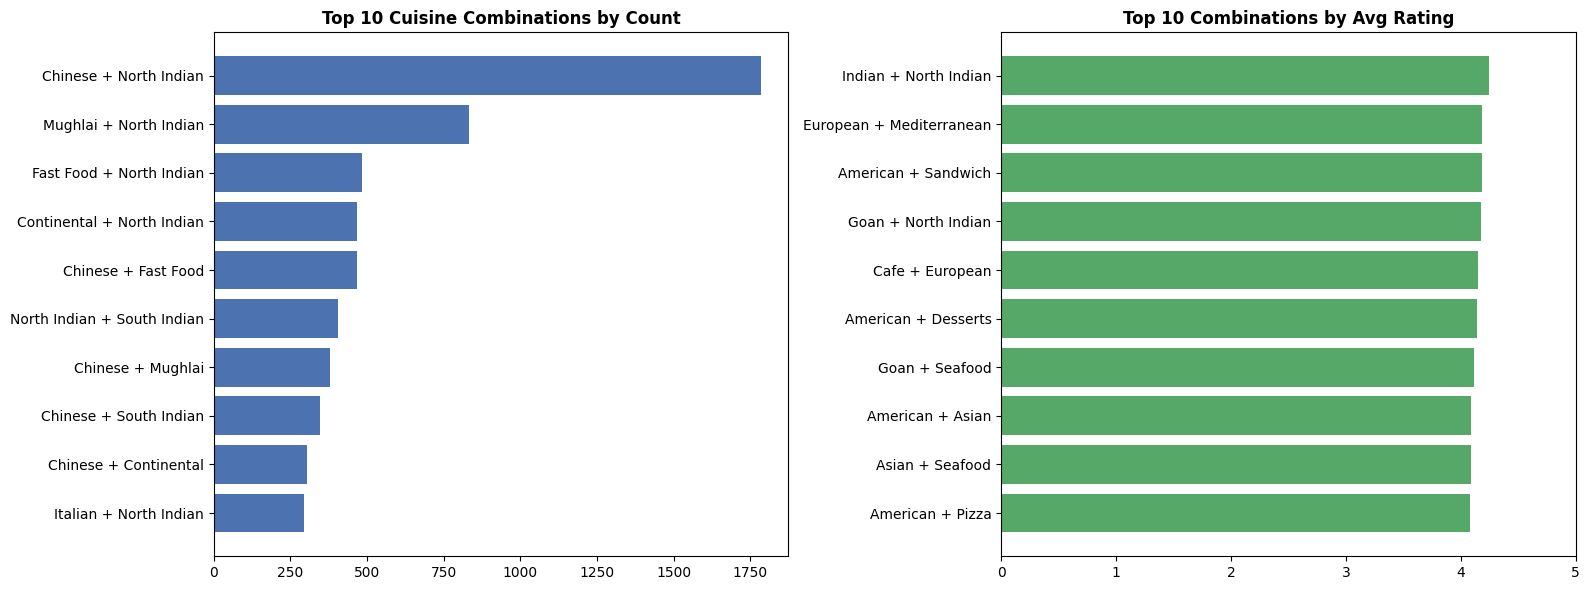

In [ ]:
# Level 2 - Task 2: Cuisine Combinations

from itertools import combinations
from collections import Counter

combo_counts  = Counter()
combo_ratings = {}

for _, row in df.dropna(subset=["Cuisines"]).iterrows():
    cuisines = [c.strip() for c in row["Cuisines"].split(",")]
    if len(cuisines) < 2:
        continue
    for combo in combinations(sorted(cuisines), 2):
        key = " + ".join(combo)
        combo_counts[key] += 1
        if row["Aggregate_rating"] > 0:
            combo_ratings.setdefault(key, []).append(row["Aggregate_rating"])

top10 = combo_counts.most_common(10)
print("Top 10 Most Common Cuisine Combinations")
print("=" * 55)
for combo, cnt in top10:
    avg = sum(combo_ratings.get(combo, [0])) / max(len(combo_ratings.get(combo, [1])), 1)
    print(f"  {combo:<40} Count: {cnt}  Avg Rating: {avg:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh([c[0] for c in top10][::-1], [c[1] for c in top10][::-1], color="#4C72B0")
axes[0].set_title("Top 10 Cuisine Combinations by Count", fontweight="bold")

top_rated = sorted({k: sum(v)/len(v) for k, v in combo_ratings.items() if len(v) >= 10}.items(),
                   key=lambda x: x[1], reverse=True)[:10]
axes[1].barh([c[0] for c in top_rated][::-1], [c[1] for c in top_rated][::-1], color="#55A868")
axes[1].set_title("Top 10 Combinations by Avg Rating", fontweight="bold")
axes[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()

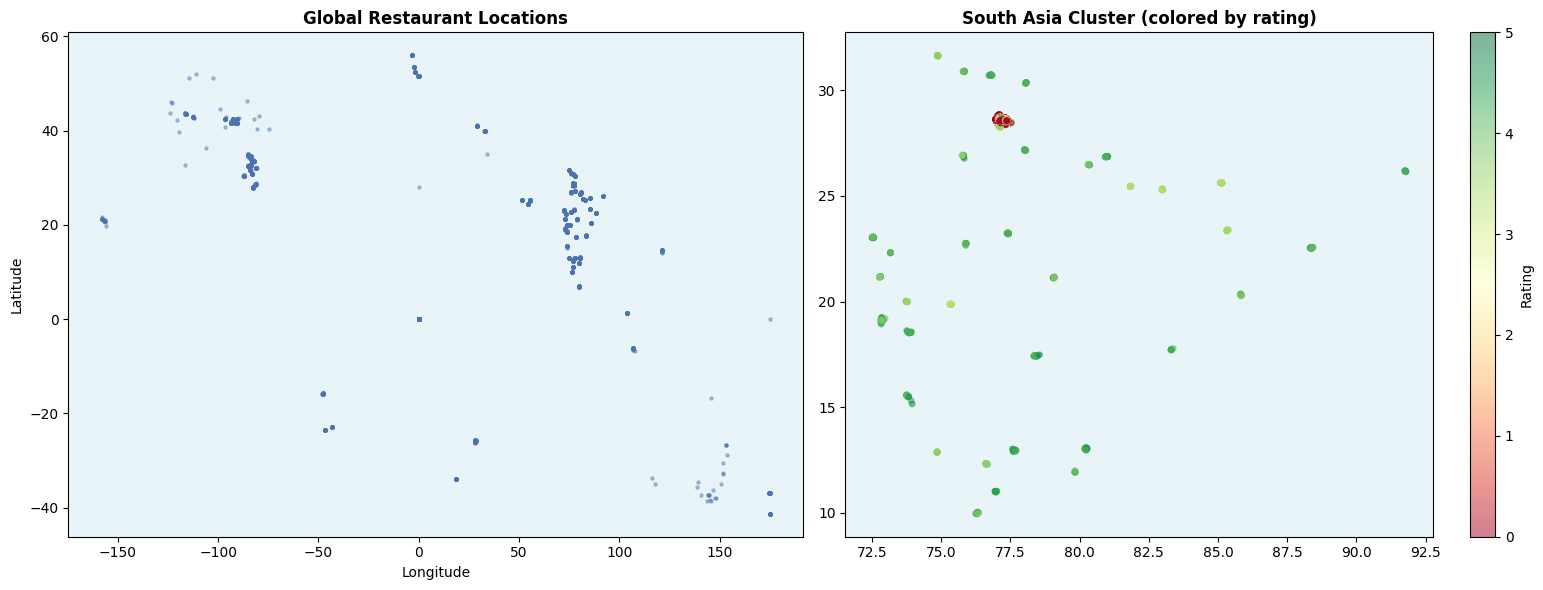


Top 10 Cities by Restaurant Count:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21


In [ ]:
# Level 2 - Task 3: Geographic Analysis

df_geo = df.dropna(subset=["Latitude", "Longitude"])
df_geo = df_geo[(df_geo["Latitude"].between(-90, 90)) &
                (df_geo["Longitude"].between(-180, 180))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df_geo["Longitude"], df_geo["Latitude"],
                s=5, alpha=0.4, color="#4C72B0")
axes[0].set_title("Global Restaurant Locations", fontweight="bold")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_facecolor("#e8f4f8")

india = df_geo[(df_geo["Latitude"].between(8, 38)) &
               (df_geo["Longitude"].between(68, 98))]
sc = axes[1].scatter(india["Longitude"], india["Latitude"],
                     c=india["Aggregate_rating"], cmap="RdYlGn",
                     s=15, alpha=0.5, vmin=0, vmax=5)
plt.colorbar(sc, ax=axes[1], label="Rating")
axes[1].set_title("South Asia Cluster (colored by rating)", fontweight="bold")
axes[1].set_facecolor("#e8f4f8")

plt.tight_layout()
plt.show()

print("\nTop 10 Cities by Restaurant Count:")
print(df_geo["City"].value_counts().head(10).to_string())

Total chains identified : 734
Total chain outlets     : 2839

Top 15 Restaurant Chains:
   Restaurant_Name  outlets  avg_rating  total_votes
    Domino's Pizza       74    2.925676         6637
   Cafe Coffee Day       67    2.997015         2412
            Subway       61    3.003279         6122
        McDonald's       47    3.410638         5290
  Green Chick Chop       44    3.097727          953
         Pizza Hut       29    3.434483         4961
         Keventers       29    3.365517         1253
   Barbeque Nation       26    4.353846        28142
             Giani       24    3.250000          849
           Barista       21    3.219048          815
    Dunkin' Donuts       19    3.631579         5971
       Sagar Ratna       19    2.963158         4038
         Starbucks       18    3.805556         7139
Pizza Hut Delivery       18    2.805556         1527
     Pind Balluchi       18    2.922222         5579


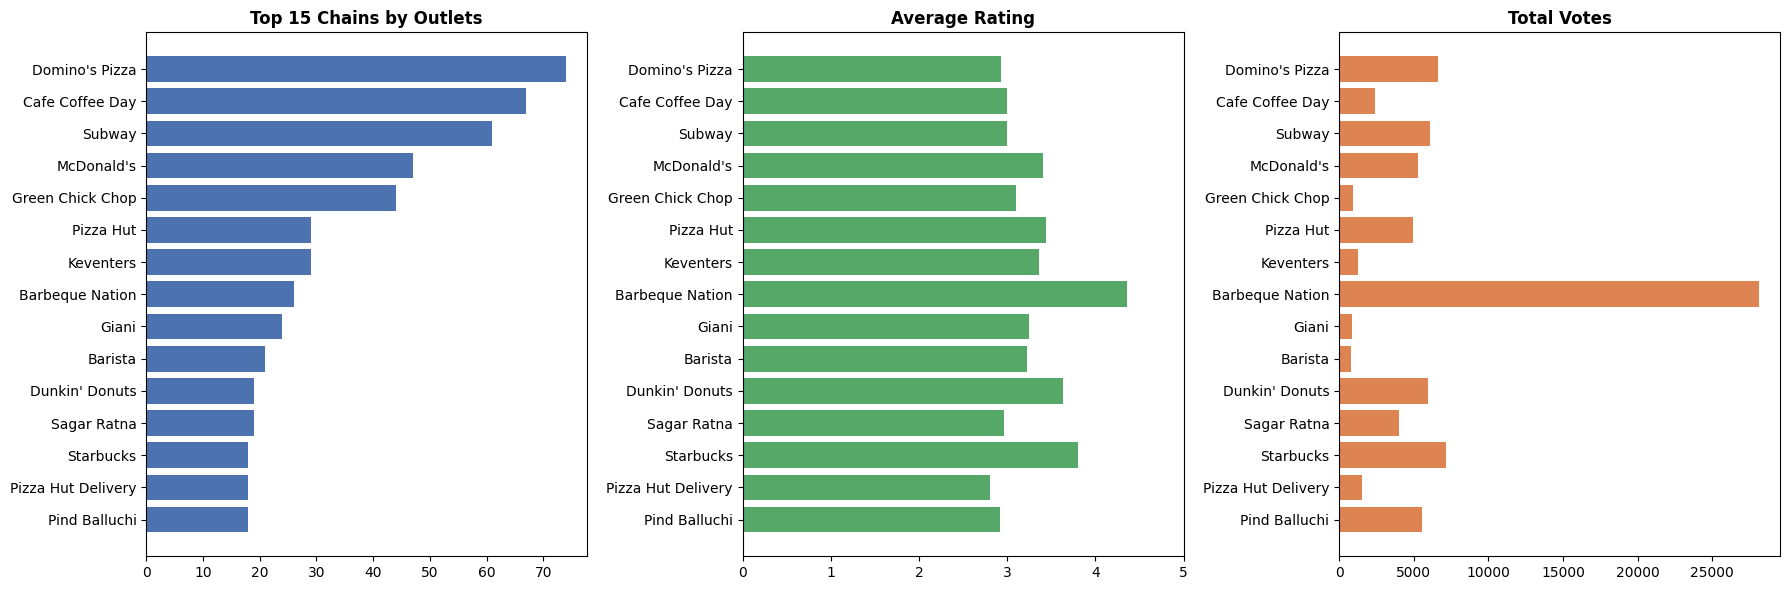

In [ ]:
# Level 2 - Task 4: Restaurant Chains

name_counts = df["Restaurant_Name"].value_counts()
chains = name_counts[name_counts > 1]
print(f"Total chains identified : {len(chains)}")
print(f"Total chain outlets     : {chains.sum()}")

chain_df = df[df["Restaurant_Name"].isin(chains.index)]
rated_chain = chain_df[chain_df["Aggregate_rating"] > 0]

chain_stats = rated_chain.groupby("Restaurant_Name").agg(
    outlets     = ("Restaurant_Name", "count"),
    avg_rating  = ("Aggregate_rating", "mean"),
    total_votes = ("Votes", "sum")
).reset_index().sort_values("outlets", ascending=False).head(15)

print("\nTop 15 Restaurant Chains:")
print(chain_stats.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].barh(chain_stats["Restaurant_Name"][::-1], chain_stats["outlets"][::-1], color="#4C72B0")
axes[0].set_title("Top 15 Chains by Outlets", fontweight="bold")

axes[1].barh(chain_stats["Restaurant_Name"][::-1], chain_stats["avg_rating"][::-1], color="#55A868")
axes[1].set_title("Average Rating", fontweight="bold")
axes[1].set_xlim(0, 5)

axes[2].barh(chain_stats["Restaurant_Name"][::-1], chain_stats["total_votes"][::-1], color="#DD8452")
axes[2].set_title("Total Votes", fontweight="bold")

plt.tight_layout()
plt.show()